In [117]:
df_decision = pd.read_excel('French_administrative_decision.xlsx')

In [118]:
df_decision.head(5)

,Unnamed: 0.1,Unnamed: 0,Identification,Code_Juridiction,Nom_Juridiction,Type_Decision,Type_Recours,Solution,Text_integral,Resultat
0,1,1,DTA_1900103_20220630.xml,TA06,Tribunal Administratif de Nice,Décision,Excès de pouvoir,Satisfaction totale,Vu la procédure suivante : Par une requête et ...,Article 1er : La décision du maire de La Turbi...
1,2,2,DTA_1901441_20220630.xml,TA06,Tribunal Administratif de Nice,Décision,Excès de pouvoir,Rejet,Vu la procédure suivante : Par un jugement ava...,Article 1er : La requête n° 1901441 de Mme B e...
2,3,3,DTA_1903583_20220630.xml,TA06,Tribunal Administratif de Nice,Décision,Excès de pouvoir,Rejet,Vu la procédure suivante : Par un jugement ava...,Article 1er : La requête n° 1903583 de Mme C e...
3,4,4,DTA_2003551_20220630.xml,TA06,Tribunal Administratif de Nice,Décision,Excès de pouvoir,Satisfaction totale,"Vu la procédure suivante : Par une requête, en...",Article 1er : La décision par laquelle le préf...
4,5,5,DTA_2003553_20220630.xml,TA06,Tribunal Administratif de Nice,Décision,Excès de pouvoir,Satisfaction totale,Vu la procédure suivante : Par une requête enr...,Article 1er : La décision par laquelle le préf...


In [64]:
df_decision.dropna(axis=0, inplace=True)


In [65]:
df_decision['Text_integral'][5]

'Vu la procédure suivante : Par une requête enregistrée le 7 septembre 2020, Mme A B, représentée par Me Rossler, demande au tribunal : 1°) d\'annuler la décision par laquelle le préfet des Alpes-Maritimes a implicitement rejeté sa demande de titre de séjour ; 2°) d\'enjoindre au préfet des Alpes-Maritimes, à titre principal, de lui délivrer un titre de séjour portant la mention " vie privée et familiale ", dans un délai de deux mois à compter de la notification du jugement à intervenir, sous astreinte de 100 euros ; 3°) d\'enjoindre au préfet des Alpes-Maritimes, à titre subsidiaire, de procéder au réexamen de sa situation, dans les mêmes conditions de délai et d\'astreinte ; 4°) de mettre à la charge de l\'Etat une somme de 1 000 euros, en application des dispositions de l\'article L. 761-1 du code de justice administrative. Elle soutient que :  - la décision en litige est insuffisamment motivée ;  - elle méconnaît les dispositions de l\'article L. 313-11 7° du code de l\'entrée et d

In [66]:
df_decision['Text_integral_clean']=''

In [67]:
import spacy  # Importing the spaCy library for natural language processing
import re  # Importing the 're' library for regular expressions (used for cleaning text)
from nltk.corpus import stopwords  # Importing stopwords from NLTK, which is a list of words to ignore (like "the", "and", etc.)
from spellchecker import SpellChecker  # Importing the spell checker for French

# Load the large French language model from spaCy, which contains in-depth linguistic features
nlp = spacy.load('fr_core_news_lg')

# Combine the stopwords from NLTK and spaCy to create a more comprehensive list of words to ignore
stop_words = set(stopwords.words('french')).union(nlp.Defaults.stop_words)

# Initialize the spell checker for French
spell = SpellChecker(language='fr')

# Function to expand common contractions in French text
def expand_contractions(text):
    """
    This function takes a text as input and replaces common French contractions
    with their full forms. For example, "l'" becomes "le", "d'" becomes "de", etc.
    """
    # Dictionary of contractions and their expanded equivalents
    contractions = {
        "l'": "le ",
        "d'": "de ",
        "j'": "je ",
        "qu'": "que ",
        "c'": "ce ",
    }
    # Replace each contraction found in the text
    for contraction, expanded in contractions.items():
        text = text.replace(contraction, expanded)
    return text  # Return the modified text

# Function to correct spelling errors in the text
def correct_spelling(text):
    """
    This function takes a text as input and corrects spelling mistakes word by word
    using a spell checker. If no correction is found, it keeps the original word.
    """
    corrected_text = []  # List to store corrected words
    # Loop over each word in the text
    for word in text.split():
        corrected_word = spell.correction(word)  # Try to correct the word
        if corrected_word is None:  # If no correction is found, keep the original word
            corrected_word = word
        corrected_text.append(corrected_word)  # Add the corrected (or original) word to the list
    return ' '.join(corrected_text)  # Return the corrected text as a string


In [68]:
import spacy
import re
from nltk.corpus import stopwords
from spellchecker import SpellChecker

# Charger le modèle large de spaCy
nlp = spacy.load('fr_core_news_lg')

# Stopwords enrichis
stop_words = set(stopwords.words('french')).union(nlp.Defaults.stop_words)

# Correcteur orthographique
spell = SpellChecker(language='fr')

# Expansion des formes contractées
def expand_contractions(text):
    contractions = {
        "l'": "le ",
        "d'": "de ",
        "j'": "je ",
        "qu'": "que ",
        "c'": "ce ",
        "n'": "ne ",
    }
    for contraction, expanded in contractions.items():
        text = text.replace(contraction, expanded)
    return text

def correct_spelling(text):
    corrected_text = []
    for word in text.split():
        corrected_word = spell.correction(word)
        if corrected_word is None:
            corrected_word = word  # Use the original word if no correction is found
        corrected_text.append(corrected_word)
    return ' '.join(corrected_text)




In [69]:
# Réindexer le DataFrame avec des numéros
df_decision = df_decision.reset_index(drop=True)
df_decision.index = df_decision.index + 1

In [70]:
df_decision.columns

Index(['Unnamed: 0', 'Identification', 'Code_Juridiction', 'Nom_Juridiction',
       'Type_Decision', 'Type_Recours', 'Solution', 'Text_integral',
       'Resultat', 'Text_integral_clean'],
      dtype='object')

In [71]:
# Appliquer l'expansion des contractions sur chaque texte
df_decision['Expanded_Contractions'] = df_decision['Text_integral'].apply(expand_contractions)


In [72]:
df_decision['Expanded_Contractions'][5]

'Vu la procédure suivante : Par une requête enregistrée le 7 septembre 2020, Mme A B, représentée par Me Rossler, demande au tribunal : 1°) de annuler la décision par laquelle le préfet des Alpes-Maritimes a implicitement rejeté sa demande de titre de séjour ; 2°) de enjoindre au préfet des Alpes-Maritimes, à titre principal, de lui délivrer un titre de séjour portant la mention " vie privée et familiale ", dans un délai de deux mois à compter de la notification du jugement à intervenir, sous astreinte de 100 euros ; 3°) de enjoindre au préfet des Alpes-Maritimes, à titre subsidiaire, de procéder au réexamen de sa situation, dans les mêmes conditions de délai et de astreinte ; 4°) de mettre à la charge de le Etat une somme de 1 000 euros, en application des dispositions de le article L. 761-1 du code de justice administrative. Elle soutient que :  - la décision en litige est insuffisamment motivée ;  - elle méconnaît les dispositions de le article L. 313-11 7° du code de le entrée et d

In [73]:
# Appliquer la correction orthographique sur chaque texte (après expansion des contractions)
df_decision['Corrected_Spelling'] = df_decision['Expanded_Contractions'].apply(correct_spelling)


In [74]:
df_decision['Corrected_Spelling'][5]

'Vu la procédure suivante : Par une requête enregistrée le 7 septembre 2020, me A bu représentée par Me rosser demande au tribunal : 1°) de annuler la décision par laquelle le préfet des Alpes-Maritimes a implicitement rejeté sa demande de titre de séjour ; 2°) de enjoindre au préfet des Alpes-Maritimes, à titre principal de lui délivrer un titre de séjour portant la mention " vie privée et familiale de dans un délai de deux mois à compter de la notification du jugement à intervenir sous astreinte de 100 euros ; 3°) de enjoindre au préfet des Alpes-Maritimes, à titre subsidiaire de procéder au réexamen de sa situation dans les mêmes conditions de délai et de astreinte ; 4°) de mettre à la charge de le état une somme de 1 000 euros en application des dispositions de le article le 761-1 du code de justice administrative Elle soutient que : - la décision en litige est insuffisamment motivée ; - elle méconnaît les dispositions de le article le 313-11 de du code de le entrée et du séjour de

In [75]:
# Nettoyage des caractères spéciaux et des chiffres sur chaque texte (après correction orthographique)
df_decision['Cleaned_Text'] =df_decision['Corrected_Spelling'].apply(lambda x: re.sub(r'\W+|\d+', ' ', x))


In [76]:
df_decision['Cleaned_Text'][5]

'Vu la procédure suivante Par une requête enregistrée le   septembre   me A bu représentée par Me rosser demande au tribunal   de annuler la décision par laquelle le préfet des Alpes Maritimes a implicitement rejeté sa demande de titre de séjour   de enjoindre au préfet des Alpes Maritimes à titre principal de lui délivrer un titre de séjour portant la mention vie privée et familiale de dans un délai de deux mois à compter de la notification du jugement à intervenir sous astreinte de   euros   de enjoindre au préfet des Alpes Maritimes à titre subsidiaire de procéder au réexamen de sa situation dans les mêmes conditions de délai et de astreinte   de mettre à la charge de le état une somme de     euros en application des dispositions de le article le     du code de justice administrative Elle soutient que la décision en litige est insuffisamment motivée elle méconnaît les dispositions de le article le     de du code de le entrée et du séjour des étrangers et du droit de asile et est ent

In [77]:
# Suppression des stopwords uniquement
def remove_stopwords(text):
    doc = nlp(text)
    tokens = [token.text for token in doc if token.text not in stop_words]
    return tokens

df_decision['Without_Stopwords'] = df_decision['Cleaned_Text'].apply(remove_stopwords)


In [78]:
df_decision['Without_Stopwords'][5]

['Vu',
 'procédure',
 'Par',
 'requête',
 'enregistrée',
 '  ',
 'septembre',
 '  ',
 'A',
 'bu',
 'représentée',
 'Me',
 'rosser',
 'demande',
 'tribunal',
 '  ',
 'annuler',
 'décision',
 'préfet',
 'Alpes',
 'Maritimes',
 'implicitement',
 'rejeté',
 'demande',
 'titre',
 'séjour',
 '  ',
 'enjoindre',
 'préfet',
 'Alpes',
 'Maritimes',
 'titre',
 'principal',
 'délivrer',
 'titre',
 'séjour',
 'portant',
 'mention',
 'vie',
 'privée',
 'familiale',
 'délai',
 'mois',
 'compter',
 'notification',
 'jugement',
 'intervenir',
 'astreinte',
 '  ',
 'euros',
 '  ',
 'enjoindre',
 'préfet',
 'Alpes',
 'Maritimes',
 'titre',
 'subsidiaire',
 'procéder',
 'réexamen',
 'situation',
 'conditions',
 'délai',
 'astreinte',
 '  ',
 'mettre',
 'charge',
 'état',
 'somme',
 '    ',
 'euros',
 'application',
 'dispositions',
 'article',
 '    ',
 'code',
 'justice',
 'administrative',
 'Elle',
 'soutient',
 'décision',
 'litige',
 'insuffisamment',
 'motivée',
 'méconnaît',
 'dispositions',
 'arti

In [79]:
# Lemmatisation without removing stopwords (ensures the input is a string)
def lemmatize(text):
    if isinstance(text, list):
        text = ' '.join(text)  # Join list of tokens into a single string
    doc = nlp(text)  # Apply spaCy NLP pipeline
    tokens = [token.lemma_ for token in doc]  # Lemmatize the tokens
    return tokens  # Return the lemmatized tokens

# Applying the function to the DataFrame
df_decision['Lemmatized'] = df_decision['Without_Stopwords'].apply(lemmatize)


In [80]:
df_decision['Lemmatized'][5]

['voir',
 'procédure',
 'par',
 'requête',
 'enregistrer',
 '   ',
 'septembre',
 '   ',
 'avoir',
 'boire',
 'représenter',
 'me',
 'rosser',
 'demande',
 'tribunal',
 '   ',
 'annuler',
 'décision',
 'préfet',
 'Alpes',
 'Maritimes',
 'implicitement',
 'rejeter',
 'demande',
 'titre',
 'séjour',
 '   ',
 'enjoindre',
 'préfet',
 'Alpes',
 'Maritimes',
 'titre',
 'principal',
 'délivrer',
 'titre',
 'séjour',
 'porter',
 'mention',
 'vie',
 'priver',
 'familial',
 'délai',
 'mois',
 'compter',
 'notification',
 'jugement',
 'intervenir',
 'astreinte',
 '   ',
 'euro',
 '   ',
 'enjoindre',
 'préfet',
 'Alpes',
 'Maritimes',
 'titre',
 'subsidiaire',
 'procéder',
 'réexamen',
 'situation',
 'condition',
 'délai',
 'astreindre',
 '   ',
 'mettre',
 'charge',
 'état',
 'somme',
 '     ',
 'euro',
 'application',
 'disposition',
 'article',
 '     ',
 'code',
 'justice',
 'administratif',
 'lui',
 'soutenir',
 'décision',
 'litige',
 'insuffisamment',
 'motiver',
 'méconnaître',
 'disposi

In [81]:
# Import necessary libraries
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Assuming your DataFrame is called df_decision and it contains the tokenized words
# Joining the list of words back into a single string for each row
df_decision['Lemmatized'] = df_decision['Lemmatized'].apply(lambda x: ' '.join(x))


In [82]:
df_decision['Lemmatized'][5]

'voir procédure par requête enregistrer     septembre     avoir boire représenter me rosser demande tribunal     annuler décision préfet Alpes Maritimes implicitement rejeter demande titre séjour     enjoindre préfet Alpes Maritimes titre principal délivrer titre séjour porter mention vie priver familial délai mois compter notification jugement intervenir astreinte     euro     enjoindre préfet Alpes Maritimes titre subsidiaire procéder réexamen situation condition délai astreindre     mettre charge état somme       euro application disposition article       code justice administratif lui soutenir décision litige insuffisamment motiver méconnaître disposition article       code entrée séjour étranger droit asile entacher erreur manifeste appréciation le requête communiquer préfet Alpes Maritimes nier produit observation défense Vu pièce dossier Vu code relation public administration code justice administratif le président formation jugement dispenser rapporteur public proposition prono

In [83]:
df_decision.to_excel('seminaire.xlsx')

In [84]:
# Check the content of df_decision['Lemmatized']
print(df_decision['Lemmatized'].head())

1    voir procédure par requête mémoire complémenta...
2    voir procédure par jugement droit     février ...
3    voir procédure par jugement droit     février ...
4    voir procédure par requête enregistrer     sep...
5    voir procédure par requête enregistrer     sep...
Name: Lemmatized, dtype: object


In [99]:
df_decision = pd.read_excel("seminaire.xlsx")

In [100]:
df_decision.head(4)

,Unnamed: 0.1,Unnamed: 0,Identification,Code_Juridiction,Nom_Juridiction,Type_Decision,Type_Recours,Solution,Text_integral,Resultat,Text_integral_clean,Expanded_Contractions,Corrected_Spelling,Cleaned_Text,Without_Stopwords,Lemmatized
0,1,1,DTA_1900103_20220630.xml,TA06,Tribunal Administratif de Nice,Décision,Excès de pouvoir,Satisfaction totale,Vu la procédure suivante : Par une requête et ...,Article 1er : La décision du maire de La Turbi...,NaN,Vu la procédure suivante : Par une requête et ...,Vu la procédure suivante : Par une requête et ...,Vu la procédure suivante Par une requête et un...,"['Vu', 'procédure', 'Par', 'requête', 'mémoire...",voir procédure par requête mémoire complémenta...
1,2,2,DTA_1901441_20220630.xml,TA06,Tribunal Administratif de Nice,Décision,Excès de pouvoir,Rejet,Vu la procédure suivante : Par un jugement ava...,Article 1er : La requête n° 1901441 de Mme B e...,NaN,Vu la procédure suivante : Par un jugement ava...,Vu la procédure suivante : Par un jugement ava...,Vu la procédure suivante Par un jugement avant...,"['Vu', 'procédure', 'Par', 'jugement', 'droit'...",voir procédure par jugement droit février ...
2,3,3,DTA_1903583_20220630.xml,TA06,Tribunal Administratif de Nice,Décision,Excès de pouvoir,Rejet,Vu la procédure suivante : Par un jugement ava...,Article 1er : La requête n° 1903583 de Mme C e...,NaN,Vu la procédure suivante : Par un jugement ava...,Vu la procédure suivante : Par un jugement ava...,Vu la procédure suivante Par un jugement avant...,"['Vu', 'procédure', 'Par', 'jugement', 'droit'...",voir procédure par jugement droit février ...
3,4,4,DTA_2003551_20220630.xml,TA06,Tribunal Administratif de Nice,Décision,Excès de pouvoir,Satisfaction totale,"Vu la procédure suivante : Par une requête, en...",Article 1er : La décision par laquelle le préf...,NaN,"Vu la procédure suivante : Par une requête, en...",Vu la procédure suivante : Par une requête enr...,Vu la procédure suivante Par une requête enreg...,"['Vu', 'procédure', 'Par', 'requête', 'enregis...",voir procédure par requête enregistrer sep...


In [101]:
# Import stopwords from nltk
import nltk
from nltk.corpus import stopwords

# Download French stopwords if not already downloaded
nltk.download('stopwords')
french_stopwords = set(stopwords.words('french'))

# Remove stopwords from the 'Lemmatized' column
df_decision['Without_Stopwords'] = df_decision['Lemmatized'].apply(lambda x: ' '.join([word for word in x.split() if word.lower() not in french_stopwords]))

# Now, use the 'Without_Stopwords' column for word frequency analysis


[nltk_data] Downloading package stopwords to C:\Users\Khaoula
[nltk_data]     Naili\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [106]:
# Ensure the 'Lemmatized' column is properly joined from lists into single strings
df_decision['Lemmatized'] = df_decision['Lemmatized'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

# Check the cleaned text
print(df_decision['Lemmatized'].head())

# Now apply CountVectorizer and LDA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk
from nltk.corpus import stopwords

# Download French stopwords if not already downloaded
nltk.download('stopwords')
french_stopwords = stopwords.words('french')

# Vectorization using CountVectorizer (for LDA)
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words=french_stopwords)
doc_term_matrix = vectorizer.fit_transform(df_decision['Without_Stopwords'])

# Apply LDA
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(doc_term_matrix)

# Print Topics
def print_topics(model, vectorizer, top_n=10):
    words = vectorizer.get_feature_names_out()
    for idx, topic in enumerate(model.components_):
        print(f"Topic {idx}:")
        print([words[i] for i in topic.argsort()[-top_n:]])

print_topics(lda_model, vectorizer)


0    voir procédure par requête mémoire complémenta...
1    voir procédure par jugement droit     février ...
2    voir procédure par jugement droit     février ...
3    voir procédure par requête enregistrer     sep...
4    voir procédure par requête enregistrer     sep...
Name: Lemmatized, dtype: object


[nltk_data] Downloading package stopwords to C:\Users\Khaoula
[nltk_data]     Naili\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Topic 0:
['service', 'valeur', 'imposition', 'général', 'année', 'administration', 'fiscal', 'taxe', 'société', 'impôt']
Topic 1:
['décision', 'plan', 'modification', 'projet', 'urbanisme', 'terrain', 'hauteur', 'construire', 'construction', 'permettre']
Topic 2:
['alpes', 'asile', 'entrée', 'français', 'familial', 'étranger', 'préfet', 'décision', 'droit', 'séjour']
Topic 3:
['préfet', 'cas', 'préfecture', 'juge', 'étranger', 'seine', 'séjour', 'délai', 'situation', 'rendez']
Topic 4:
['requérir', 'somme', 'rapport', 'état', 'public', 'intérêt', 'travail', 'frontière', 'regroupement', 'euro']


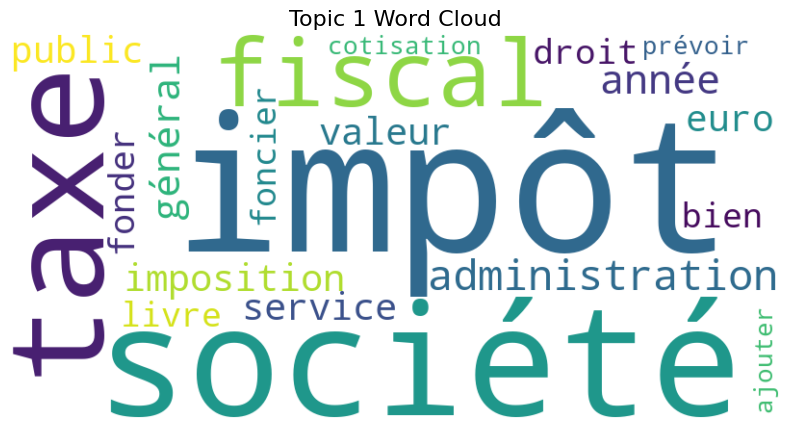

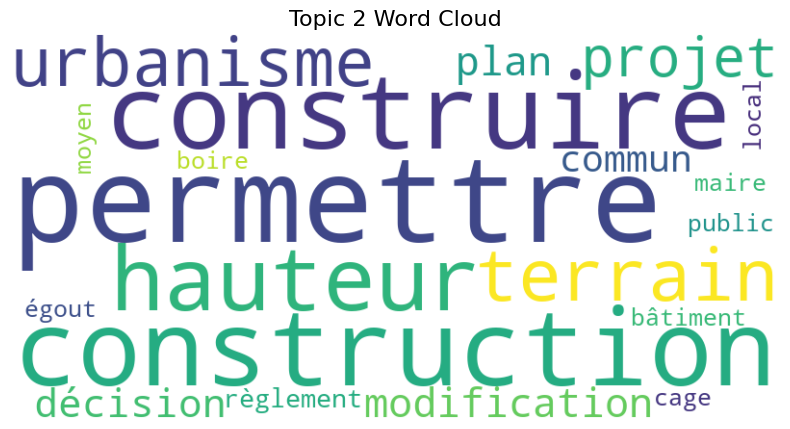

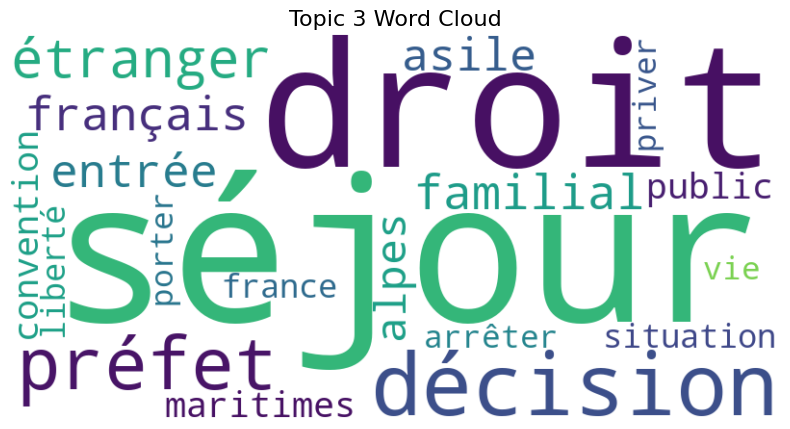

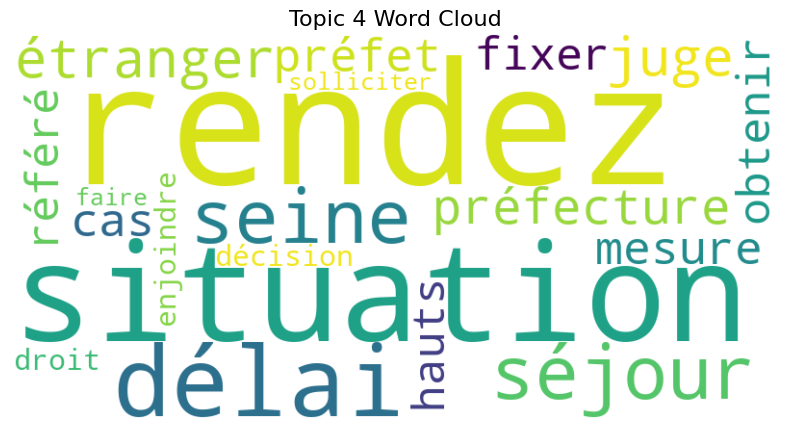

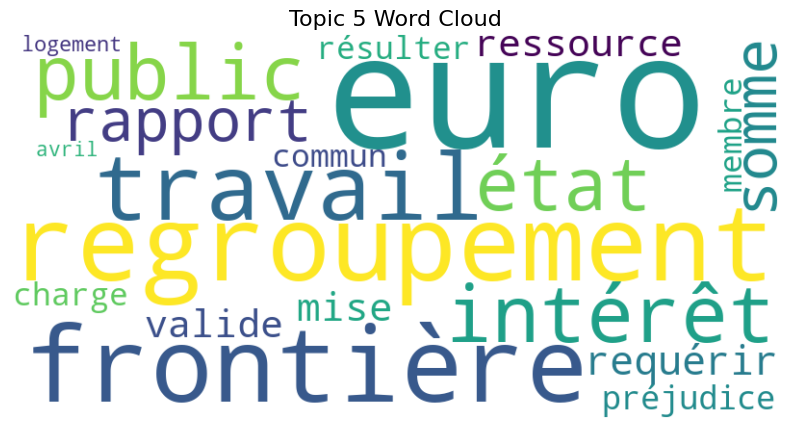

In [107]:
# Import necessary libraries for word cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Function to generate word cloud for each topic
def plot_word_cloud(lda_model, vectorizer, num_topics=5):
    words = vectorizer.get_feature_names_out()
    for idx, topic in enumerate(lda_model.components_[:num_topics]):
        # Create a dictionary of word and its importance (topic weight)
        word_freq = {words[i]: topic[i] for i in topic.argsort()[-20:]}  # Top 20 words per topic
        # Generate word cloud
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
        # Plot the word cloud
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Topic {idx+1} Word Cloud', fontsize=16)
        plt.show()

# Generate word clouds for LDA topics
plot_word_cloud(lda_model, vectorizer, num_topics=5)


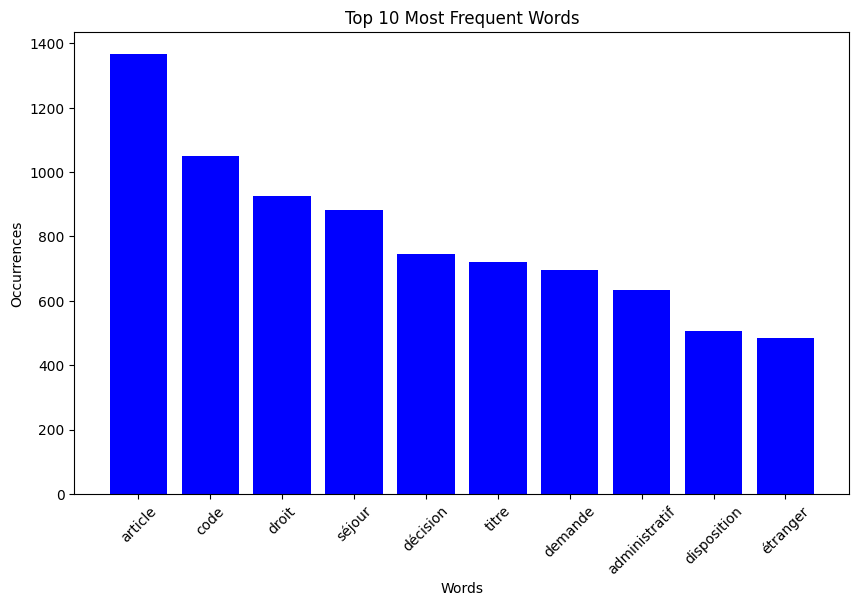

In [108]:
import matplotlib.pyplot as plt
from collections import Counter

# Join all the lemmatized text into a single string
all_words = ' '.join(df_decision['Without_Stopwords'])

# Tokenize the words by splitting the string
words = all_words.split()

# Use Counter to count word occurrences
word_counts = Counter(words)

# Get the top 10 most common words
top_words = word_counts.most_common(10)

# Separate the words and their counts for plotting
words, counts = zip(*top_words)

# Plotting the histogram of word occurrences
plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='blue')
plt.title('Top 10 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Occurrences')
plt.xticks(rotation=45)
plt.show()


In [109]:
# Import the necessary library
from textblob import TextBlob

# Function to apply sentiment analysis
def analyze_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity  # Returns a value between -1 (negative) and 1 (positive)

# Apply sentiment analysis to the Lemmatized column
df_decision['Sentiment'] = df_decision['Without_Stopwords'].apply(lambda x: analyze_sentiment(x))

# Display the results
print(df_decision[['Lemmatized', 'Sentiment']].head())


                                          Lemmatized  Sentiment
0  voir procédure par requête mémoire complémenta...  -0.004500
1  voir procédure par jugement droit     février ...   0.000000
2  voir procédure par jugement droit     février ...   0.000000
3  voir procédure par requête enregistrer     sep...  -0.001563
4  voir procédure par requête enregistrer     sep...  -0.002083
